# FishWood — CDF weight refinement vs equal-spaced weights

Tabular policy optimization with KL regularization toward uniform $\pi_{\mathrm{ref}}$, matching the structure of `Policy_update_DST_with_baseline.ipynb`. The FishWood MDP follows [MO-Gymnasium FishWood](https://mo-gymnasium.farama.org/environments/fishwood/) (see source: two states, two actions, next state equals action; expected rewards use `fishproba` / `woodproba`).

In [16]:
import os
import time
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

# NumPy 2.0 removed np.round_; morl_baselines LinearSupport still uses the old alias.
if not hasattr(np, "round_"):
    np.round_ = np.round

import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.interpolate import PchipInterpolator

DEVICE = "cpu"
FIG_PATH = "figure/"
os.makedirs(FIG_PATH, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (7, 5),
    "figure.dpi": 120,
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "legend.fontsize": 12,
    "lines.linewidth": 2.0,
    "lines.markersize": 8,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.5,
    "legend.frameon": False,
    "figure.autolayout": True,
})


## A. Tabular FishWood model (expected rewards)

State `0`: fishing; state `1`: woods. Reward is drawn in the **current** state, then `next_state = action` (0 = go fish, 1 = collect wood). We use expectations so $R$ is deterministic (same convention as using a large-horizon discounted surrogate).

In [17]:
def build_fishwood_tabular_model(fishproba=0.1, woodproba=0.9):
    """
    S=2 (0 fish, 1 woods), A=2. Transition: s' = a with probability 1.
    R[s,a,0] = fish rate in state 0, else 0; R[s,a,1] = wood rate in state 1, else 0.
    Initial state: woods (index 1).
    """
    S, A = 2, 2
    P = np.zeros((S, A, S), dtype=np.float32)
    for s in range(S):
        for a in range(A):
            P[s, a, a] = 1.0
    R = np.zeros((S, A, 2), dtype=np.float32)
    R[0, :, 0] = float(fishproba)
    R[1, :, 1] = float(woodproba)
    rho0 = np.array([0.0, 1.0], dtype=np.float32)
    return {"S": S, "A": A, "P": P, "R": R, "rho0": rho0, "fishproba": fishproba, "woodproba": woodproba}


def build_fishwood_model_from_mogym(env_id="fishwood-v0", fishproba=0.1, woodproba=0.9):
    """
    Prefer the official environment constructor, thene convert to the same tabular expected modl.
    Falls back to direct tabular build if mo_gymnasium is unavailable.
    """
    try:
        import mo_gymnasium as mo_gym
        env = mo_gym.make(env_id, fishproba=fishproba, woodproba=woodproba)
        uenv = env.unwrapped
        fp = float(getattr(uenv, "_fishproba", fishproba))
        wp = float(getattr(uenv, "_woodproba", woodproba))
        print(f"fp: {fp}, wp: {wp}")
        env.close()
        return build_fishwood_tabular_model(fishproba=fp, woodproba=wp)
    except Exception as e:
        print(f"[info] mo_gymnasium not available or failed ({e}); using direct tabular FishWood model.")
        return build_fishwood_tabular_model(fishproba=fishproba, woodproba=woodproba)


def make_equispace_pi_ref(S, A):
    return np.full((S, A), 1.0 / A, dtype=np.float32)


def discounted_state_dist_from_policy_torch(pi, P_t, rho0_t, gamma):
    P_pi = torch.einsum("sa,san->sn", pi, P_t)
    I = torch.eye(P_pi.shape[0], dtype=P_pi.dtype, device=P_pi.device)
    M = I - gamma * P_pi
    rhs = (1.0 - gamma) * rho0_t
    d = torch.linalg.solve(M.T, rhs)
    return d


def evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t):
    pi = F.softmax(logits, dim=-1)
    d = discounted_state_dist_from_policy_torch(pi, P_t, rho0_t, gamma)
    mu = d.unsqueeze(-1) * pi
    R1 = torch.sum(mu * R_t[..., 0])
    R2 = torch.sum(mu * R_t[..., 1])
    log_pi = torch.log(pi + 1e-12)
    log_pi_ref = torch.log(pi_ref_t + 1e-12)
    kl_state = torch.sum(pi * (log_pi - log_pi_ref), dim=-1)
    reg = tau * torch.sum(d * kl_state)
    return {"pi": pi, "d": d, "mu": mu, "R1": R1, "R2": R2, "reg": reg, "obj_vec": torch.stack([R1, R2])}


def scalarized_objective_torch(logits, w, P_t, R_t, rho0_t, gamma, tau, pi_ref_t):
    out = evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
    scalar = (1.0 - w) * out["R1"] + w * out["R2"] - out["reg"]
    return scalar, out


def solve_policy_scalarization(
    w, P, R, rho0, gamma, tau, pi_ref,
    logits_init=None, lr=0.05, maxiter=400, tol=1e-8, device=DEVICE, verbose=False,
):
    P_t = torch.tensor(P, dtype=torch.float32, device=device)
    R_t = torch.tensor(R, dtype=torch.float32, device=device)
    rho0_t = torch.tensor(rho0, dtype=torch.float32, device=device)
    pi_ref_t = torch.tensor(pi_ref, dtype=torch.float32, device=device)
    S, A = pi_ref.shape
    if logits_init is None:
        logits = torch.zeros((S, A), dtype=torch.float32, device=device, requires_grad=True)
    else:
        logits = torch.tensor(logits_init, dtype=torch.float32, device=device, requires_grad=True)
    opt = torch.optim.Adam([logits], lr=lr)
    prev_val = None
    for it in range(maxiter):
        opt.zero_grad()
        scalar, out = scalarized_objective_torch(logits, w, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
        (-scalar).backward()
        opt.step()
        val = scalar.item()
        if prev_val is not None and abs(val - prev_val) < tol:
            break
        prev_val = val
    with torch.no_grad():
        scalar, out = scalarized_objective_torch(logits, w, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
    return {
        "w": w,
        "logits": logits.detach().cpu().numpy(),
        "pi": out["pi"].detach().cpu().numpy(),
        "R1": out["R1"].item(),
        "R2": out["R2"].item(),
        "reg": out["reg"].item(),
        "scalar": scalar.item(),
    }

## B. CDF refinement (arc-length on objective polyline) + equal-spaced baseline

In [18]:
def policy_from_mu(mu, pi_ref, d_eps=1e-12, tiny=1e-32):
    mu = np.asarray(mu, dtype=np.float64)
    pi_ref = np.asarray(pi_ref, dtype=np.float64)
    d = mu.sum(axis=1)
    pi = np.array(pi_ref, copy=True)
    active = d > d_eps
    pi[active] = mu[active] / d[active, None]
    pi = np.clip(pi, tiny, 1.0)
    pi = pi / pi.sum(axis=1, keepdims=True)
    return pi, d


def logits_from_policy(pi, tiny=1e-32):
    pi = np.clip(np.asarray(pi, dtype=np.float64), tiny, 1.0)
    logits = np.log(pi)
    return logits - logits.mean(axis=1, keepdims=True)


def solve_cdf_refinement_policy(
    N_points, P, R, rho0, gamma, tau, pi_ref,
    max_outer_iters=12, alpha=0.8,
    inner_maxiter=100, inner_lr=0.05, inner_tol=1e-8,
    logits0=None, logits1=None, mu0=None, mu1=None,
    d_eps=1e-12, init_from_prev=True, device=DEVICE, verbose=False,
):
    quantiles = np.linspace(0.0, 1.0, N_points)
    fine_w = np.linspace(0.0, 1.0, 201)
    F_vals = fine_w.copy()
    F_history = [F_vals.copy()]
    S, A = pi_ref.shape
    current_logits = [None for _ in range(N_points)]

    if mu0 is not None and mu1 is not None:
        mu0 = np.asarray(mu0, dtype=np.float64)
        mu1 = np.asarray(mu1, dtype=np.float64)
        for i, q in enumerate(quantiles):
            mu_q = np.maximum((1.0 - q) * mu0 + q * mu1, 0.0)
            pi_q, _ = policy_from_mu(mu_q, pi_ref, d_eps=d_eps)
            current_logits[i] = logits_from_policy(pi_q)
    elif logits0 is not None and logits1 is not None:
        current_logits = [(1.0 - q) * logits0 + q * logits1 for q in quantiles]

    pf_history = []
    policy_history = []
    weight_history = []

    for t in range(max_outer_iters):
        current_w = np.interp(quantiles, F_vals, fine_w)
        weight_history.append(current_w.copy())
        if verbose:
            print(f"--- outer {t} ---\nweights:", np.round(current_w, 4))

        results_t = []
        f_coords = []
        for n, w in enumerate(current_w):
            if init_from_prev and current_logits[n] is not None:
                logits_init = current_logits[n]
            elif logits0 is not None and logits1 is not None:
                logits_init = (1.0 - w) * logits0 + w * logits1
            else:
                logits_init = np.zeros((S, A), dtype=np.float32)

            sol = solve_policy_scalarization(
                w, P, R, rho0, gamma, tau, pi_ref,
                logits_init=logits_init, lr=inner_lr, maxiter=inner_maxiter, tol=inner_tol, device=device, verbose=False,
            )
            current_logits[n] = sol["logits"]
            results_t.append(sol)
            f_coords.append([sol["R1"], sol["R2"]])

        f_coords = np.asarray(f_coords, dtype=np.float32)
        pf_history.append(f_coords)
        policy_history.append(results_t)

        diffs = np.diff(f_coords, axis=0)
        seg_lens = np.sqrt(np.sum(diffs ** 2, axis=1))
        s_vals = np.concatenate([[0.0], np.cumsum(seg_lens)])
        total_len = s_vals[-1]
        if total_len <= 1e-14:
            break
        tilde_F_values = s_vals / total_len
        interp_tilde_F = PchipInterpolator(current_w, tilde_F_values)
        tilde_vals = interp_tilde_F(fine_w)
        F_vals = (1.0 - alpha) * F_vals + alpha * tilde_vals
        F_vals = np.maximum.accumulate(F_vals)
        F_vals[0] = 0.0
        F_vals[-1] = 1.0
        F_history.append(F_vals.copy())

    final_w = np.interp(quantiles, F_vals, fine_w)
    return {
        "final_w": final_w,
        "final_logits": current_logits,
        "pf_history": pf_history,
        "policy_history": policy_history,
        "weight_history": weight_history,
        "F_history": F_history,
        "F_grid_w": fine_w,
        "F_grid_vals": F_vals,
    }


def run_equispace_weights_policy_baseline(
    N_points, P, R, rho0, gamma, tau, pi_ref,
    inner_maxiter=400, inner_lr=0.05, inner_tol=1e-8, device=DEVICE,
):
    weights = np.linspace(0.0, 1.0, N_points)
    results = []
    pf = []
    for w in weights:
        sol = solve_policy_scalarization(
            w, P, R, rho0, gamma, tau, pi_ref,
            logits_init=None, lr=inner_lr, maxiter=inner_maxiter, tol=inner_tol, device=device, verbose=False,
        )
        results.append(sol)
        pf.append([sol["R1"], sol["R2"]])
    return {"weights": weights, "results": results, "pf": np.asarray(pf, dtype=np.float64)}

## C. Run experiment and plot Pareto-front coverage

Dense equal-weight sweep serves as a visual reference for the frontier. CDF refinement re-allocates the same number of scalarizations along arc length in return space.

In [19]:
fishproba, woodproba = 0.1, 0.9
model = build_fishwood_model_from_mogym("fishwood-v0", fishproba=fishproba, woodproba=woodproba)
P, R, rho0 = model["P"], model["R"], model["rho0"]
S, A = model["S"], model["A"]
gamma = 0.995
tau = 0.5
pi_ref = make_equispace_pi_ref(S, A)

N_sparse = 11
N_ref = 201

# Shared budgets — Section E reference table (keep identical in cells 7, 9, 12).
INNER_MAXITER = 100
INNER_LR = 0.05
CDF_MAX_OUTER_ITERS = 13
CDF_ALPHA = 0.8
CDF_INIT_FROM_PREV = False
UMOD_MAX_OUTER_ITERS = 6
UMOD_PF_MODEL_EPOCHS = 80
OLS_INNER_MAXITER = 100
ALGO_SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# Figure-3 baselines (DST §E): NBI, eps-constraint, continuation, equal-spacing
FIG3_AL_INNER_MAXITER = 3000
FIG3_AL_INNER_LR = 0.02
FIG3_EPS_RHO = 50.0
FIG3_NBI_RHO = 10.0
FIG3_AL_PERIOD = 50
FIG3_CONT_INNER_MAXITER = 200
FIG3_CONT_INNER_LR = 0.02
FIG3_CONT_N_PROBE = 9
FIG3_EQSP_INNER_MAXITER = 300
FIG3_EQSP_INNER_LR = 0.02
FIG3_EQSP_N_PROBE = 9
FIG3_EQSP_BISECT_ITERS = 20
FIG3_EQSP_CHORD_RTOL = 5e-3

# Endpoints for logit interpolation init (optional)
sol_w0 = solve_policy_scalarization(0.0, P, R, rho0, gamma, tau, pi_ref)
sol_w1 = solve_policy_scalarization(1.0, P, R, rho0, gamma, tau, pi_ref)
logits0, logits1 = sol_w0["logits"], sol_w1["logits"]

out_dense = run_equispace_weights_policy_baseline(
    N_ref, P, R, rho0, gamma, tau, pi_ref,
    inner_maxiter=INNER_MAXITER, inner_lr=INNER_LR,
)
pf_ref = out_dense["pf"]

out_equi = run_equispace_weights_policy_baseline(
    N_sparse, P, R, rho0, gamma, tau, pi_ref,
    inner_maxiter=INNER_MAXITER, inner_lr=INNER_LR,
)

out_cdf = solve_cdf_refinement_policy(
    N_sparse, P, R, rho0, gamma, tau, pi_ref,
    max_outer_iters=CDF_MAX_OUTER_ITERS,
    alpha=CDF_ALPHA,
    logits0=logits0, logits1=logits1,
    init_from_prev=CDF_INIT_FROM_PREV,
    inner_maxiter=INNER_MAXITER,
    inner_lr=INNER_LR,
    verbose=False,
)
pf_cdf = out_cdf["pf_history"][-1]

# fig, ax = plt.subplots()
# ax.plot(pf_ref[:, 0], pf_ref[:, 1], color="0.75", lw=3, label="Reference PF (equi $w$, dense)")
# ax.scatter(out_equi["pf"][:, 0], out_equi["pf"][:, 1], s=80, marker="s", c="#d62728", zorder=5, label=f"Equal-spaced $w$ ($N={N_sparse}$)")
# ax.scatter(pf_cdf[:, 0], pf_cdf[:, 1], s=70, c="#1f77b4", zorder=6, label=f"CDF refinement ($N={N_sparse}$)")
# for i in range(len(pf_cdf)):
#     ax.annotate(str(i), (pf_cdf[i, 0], pf_cdf[i, 1]), textcoords="offset points", xytext=(4, 4), fontsize=8, color="#1f77b4")
# ax.set_xlabel(r"Expected discounted fish ($R_1$)")
# ax.set_ylabel(r"Expected discounted wood ($R_2$)")
# ax.set_title(f"FishWood PF coverage ($\\gamma={gamma}$, $\\tau={tau}$, fish={fishproba}, wood={woodproba})")
# ax.legend(loc="best")
# fp = FIG_PATH + "fishwood_pf_coverage.pdf"
# plt.savefig(fp, bbox_inches="tight")
# plt.show()
# print("Saved", fp)

fp: 0.1, wp: 0.9


## D. PF coverage metrics (as in `Policy_update_DST_with_baseline.ipynb`)

**IGD** — inverted generational distance to the dense reference front. **$\widetilde{\mathrm{Err}}_{\mathrm{arc}}$** — RMS relative deviation of consecutive arc-length segments from uniform spacing along the sample polyline. **CV** — coefficient of variation of segment lengths. **|GapRatio − 1|** — with GapRatio = max segment / min segment on that polyline.

**HV (pymoo)** — [Hypervolume](https://pymoo.org/misc/indicators.html) via `pymoo.indicators.hv.HV` (moocore backend in pymoo). Objectives are **maximized** here, so we pass **minimization** objectives `F = -pf` and a `ref_point` that **dominates** all rows of `F` (same pattern as the pymoo docs example with `ref_point = np.array([1.2, 1.2])`).

**HV (compute_hv.py)** — same 2D sweep as `compute_hv()` in `compute_hv.py` (sorted by first objective), with a **maximization** reference corner `ref_point` (e.g. `[0, 0]` when all returns are nonnegative).

**Expected utility** — mean of $\lambda^\top r$ with $\lambda = [1-w,\, w]$ and $r=[R_1,R_2]$ for each solved weight $w$, matching the dot-product utility in `compute_hv.py`.

**Episodic dominance (COLA)** — as in `27137_COLA_Towards_Efficient_M.pdf` (same subsection as UT): $\\mathrm{ED}_{1,2} := \\mathbb{E}_{\\omega \\sim \\Omega}[\\mathbf{1}\\{\\sum_t \\omega^\\top r_t^{(1)} > \\sum_t \\omega^\\top r_t^{(2)}\\}]$ with vector rewards $r_t$ and episode lengths $T_1,T_2$ (we use a common horizon here). We take $\\Omega$ as in UT for $M=2$: sample $\\lambda \\sim \\mathrm{Unif}(0,1)$ and $\\omega=(\\lambda, 1-\\lambda)$, pick the policy on each front whose scalar weight $w$ is closest to $\\lambda$, then one stochastic FishWood rollout per side. **EpisodicDominance** in the table is the **average** of this directed $\\mathrm{ED}$ over **all other algorithms**, matching the paper’s “pairwise … report the average”. Tune `ED_N_EPISODES`, `ED_HORIZON`, `ED_SEED` in the metrics cell as needed. 

Run this cell after the experiment cell that defines `out_dense`, `out_equi`, and `out_cdf`.

In [20]:
import hashlib

def front_segment_lengths(pf):
    pf = np.asarray(pf, dtype=float)
    if len(pf) < 2:
        return np.array([])
    return np.sqrt(np.sum(np.diff(pf, axis=0) ** 2, axis=1))


def arc_length_cv(pf):
    """std(seg)/mean(seg) with population std (ddof=0); """
    segs = front_segment_lengths(pf)
    segs_pos = segs[segs > 1e-15]
    if len(segs_pos) < 2:
        return np.nan
    mu = np.mean(segs_pos)
    if mu <= 1e-15:
        return np.nan
    return float(np.std(segs_pos, ddof=0) / mu)


def max_min_gap_ratio(pf):
    segs = front_segment_lengths(pf)
    segs_pos = segs[segs > 1e-15]
    if len(segs_pos) == 0:
        return np.nan
    return np.max(segs_pos) / np.min(segs_pos)


def calculate_relative_rms_err(pf):
    """
    Err_arc: RMS of (segment_len / mean_seg) - 1 over positive-length segments.
    
    """
    pf = np.asarray(pf, dtype=float)
    if len(pf) < 2:
        return np.nan
    seg_lens = np.sqrt(np.sum(np.diff(pf, axis=0) ** 2, axis=1))
    seg_lens = seg_lens[seg_lens > 1e-15]
    if len(seg_lens) < 2:
        return np.nan
    L = np.sum(seg_lens)
    N_segments = len(seg_lens)
    if L < 1e-12:
        return 0.0
    ideal_len = L / N_segments
    relative_deviations = (seg_lens / ideal_len) - 1.0
    return np.sqrt(np.mean(relative_deviations ** 2))


def igd(pf, ref_pf):
    """
    IGD(P, R) = mean_{r in R} min_{p in P} ||r - p||_2. Lower is better.
    """
    pf = np.asarray(pf, dtype=float)
    ref_pf = np.asarray(ref_pf, dtype=float)
    if len(pf) == 0 or len(ref_pf) == 0:
        return np.nan
    dists = np.linalg.norm(ref_pf[:, None, :] - pf[None, :, :], axis=2)
    return np.mean(np.min(dists, axis=1))


def compute_hv(objs, ref_point):
    """2D hypervolume sweep exactly as in `compute_hv.py` (objs sorted by first objective)."""
    objs = np.asarray(objs, dtype=float)
    if len(objs) == 0:
        return 0.0
    objs = objs[objs[:, 0].argsort()]
    ref_point = np.asarray(ref_point, dtype=float)
    x, hv = ref_point[0], 0.0
    for i in range(len(objs)):
        hv += (max(ref_point[0], objs[i, 0]) - x) * (max(ref_point[1], objs[i, 1]) - ref_point[1])
        x = max(ref_point[0], objs[i, 0])
    return hv


def hypervolume_pymoo_maximize(pf, ref_point=None):
    """
    pymoo HV for maximization of (R1, R2): pass F = -pf, ref_point as in
    https://pymoo.org/misc/indicators.html (must dominate all F row-wise).
    Default ref_point=[1.2, 1.2] works when all entries of -pf are below 1.2.
    """
    try:
        from pymoo.indicators.hv import HV
    except ImportError:
        return np.nan
    pf = np.asarray(pf, dtype=float)
    if len(pf) == 0:
        return np.nan
    F = -pf
    if ref_point is None:
        ref_point = np.array([0, 0], dtype=float)
    else:
        ref_point = np.asarray(ref_point, dtype=float)
    # Ensure ref dominates F (pymoo minimization convention)
    ref_point = np.maximum(ref_point, np.max(F, axis=0) + 1e-12)
    ind = HV(ref_point=ref_point)
    return float(ind(F))


def expected_utility_per_solution(results):
    """λ·r with λ=[1-w, w] as in `compute_hv.py` preference dot product."""
    u = []
    for s in results:
        w = float(s["w"])
        u.append((1.0 - w) * s["R1"] + w * s["R2"])
    return np.asarray(u, dtype=float)


def _softmax_rows(logits):
    logits = np.asarray(logits, dtype=np.float64)
    z = logits - np.max(logits, axis=-1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=-1, keepdims=True)


def fishwood_episode_return(pi, fishproba, woodproba, start_state=1, horizon=200, rng=None):
    """
    One FishWood episode (MO-Gymnasium semantics): reward in current state, then s' = action.
    Return vector [fish, wood] = [dim0, dim1].
    """
    if rng is None:
        rng = np.random.default_rng()
    pi = np.asarray(pi, dtype=np.float64)
    s = int(start_state)
    G = np.zeros(2, dtype=np.float64)
    for _ in range(int(horizon)):
        p = np.clip(pi[s], 1e-12, 1.0)
        p = p / np.sum(p)
        a = int(rng.choice(2, p=p))
        if s == 1 and rng.random() < woodproba:
            G[1] += 1.0
        elif s == 0 and rng.random() < fishproba:
            G[0] += 1.0
        s = a
    return G


def cola_episodic_dominance_pairwise(
    results_a,
    results_b,
    fishproba,
    woodproba,
    n_episodes=256,
    horizon=200,
    base_seed=0,
    start_state=1,
):
    """
    COLA (27137_COLA_Towards_Efficient_M.pdf) Episodic Dominance for two algorithms:
        ED_{1,2} = E_{ω∼Ω}[ 1{ Σ_t ω^T r^1_t > Σ_t ω^T r^2_t } ]
    with the same Ω as UT (linear scalarization weights). For M=2 we take ω=(λ, 1-λ), λ~U(0,1).
    Policies are matched to λ by nearest scalar weight w on each front, then one independent
    rollout per algorithm per MC sample (same horizon T for both).
    """
    if len(results_a) == 0 or len(results_b) == 0:
        return np.nan

    w_a = np.array([float(s["w"]) for s in results_a], dtype=np.float64)
    w_b = np.array([float(s["w"]) for s in results_b], dtype=np.float64)

    dom = 0
    for ep in range(int(n_episodes)):
        rng_omega = np.random.default_rng(base_seed + 17 + ep * 7919)
        lam = float(rng_omega.uniform(0.0, 1.0))
        omega = np.array([lam, 1.0 - lam], dtype=np.float64)
        ia = int(np.argmin(np.abs(w_a - lam)))
        ib = int(np.argmin(np.abs(w_b - lam)))
        pi_a = _softmax_rows(results_a[ia]["logits"])
        pi_b = _softmax_rows(results_b[ib]["logits"])
        seed_r = int(base_seed + 100_003 * ep)
        g_a = fishwood_episode_return(
            pi_a, fishproba, woodproba, start_state, horizon, np.random.default_rng(seed_r)
        )
        g_b = fishwood_episode_return(
            pi_b, fishproba, woodproba, start_state, horizon, np.random.default_rng(seed_r + 500_000)
        )
        u_a = float(omega @ g_a)
        u_b = float(omega @ g_b)
        if u_a > u_b:
            dom += 1
    return float(dom) / float(n_episodes)


def mean_pairwise_cola_ed(all_results, method_name, fishproba, woodproba, n_episodes, horizon, base_seed, start_state=1):
    """Average COLA ED_{method, other} over every other algorithm in `all_results` (directed)."""
    if method_name not in all_results:
        return np.nan
    others = [n for n in all_results.keys() if n != method_name]
    if not others:
        return np.nan
    vals = []
    for opp in others:
        h = int(hashlib.md5(f"{method_name}|{opp}".encode()).hexdigest()[:8], 16)
        seed = int(base_seed + (h % 1_000_000))
        m = cola_episodic_dominance_pairwise(
            all_results[method_name],
            all_results[opp],
            fishproba,
            woodproba,
            n_episodes=n_episodes,
            horizon=horizon,
            base_seed=seed,
            start_state=start_state,
        )
        if np.isfinite(m):
            vals.append(m)
    return float(np.mean(vals)) if vals else np.nan


def pareto_metrics_vs_ref(pf, ref_pf, hv_ref_pymoo=None, hv_ref_sweep=None):
    """DST-style metrics plus HV (pymoo) and HV (compute_hv sweep)."""
    out = {
        r"$\widetilde{\mathrm{Err}}_{\mathrm{arc}}$": calculate_relative_rms_err(pf),
        "CV": arc_length_cv(pf),
        "GapRatio - 1": np.abs(max_min_gap_ratio(pf) - 1.0),
        "IGD": igd(pf, ref_pf),
        "HV (pymoo)": hypervolume_pymoo_maximize(pf, ref_point=hv_ref_pymoo),
        "HV (compute_hv.py)": compute_hv(pf, hv_ref_sweep if hv_ref_sweep is not None else np.array([0.0, 0.0])),
    }
    return out


_PF_METRIC_SPEC = (
    (r"$\widetilde{\mathrm{Err}}_{\mathrm{arc}}$", "Err_arc"),
    ("CV", "CV"),
    ("GapRatio - 1", "GapRatio_m1"),
    ("IGD", "IGD"),
    ("HV (pymoo)", "HV_pymoo"),
    ("HV (compute_hv.py)", "HV_sweep"),
)
_PF_METRIC_KEYS = tuple(k for k, _ in _PF_METRIC_SPEC)
METRIC_SLUGS = dict(_PF_METRIC_SPEC)
def _collapse_consecutive_pf_points(pf, tol=1e-12):
    """Sort by R1 and drop near-duplicate consecutive vertices (stabilizes segment-based metrics)."""
    pf = np.asarray(pf, dtype=np.float64)
    if len(pf) <= 1:
        return pf
    pf = pf[np.argsort(pf[:, 0])]
    out = [pf[0]]
    for i in range(1, len(pf)):
        if np.linalg.norm(pf[i] - out[-1]) > tol:
            out.append(pf[i])
    return np.asarray(out, dtype=np.float64)


def cola_ed_mean_std_over_seeds(
    all_results, method_name, fishproba, woodproba, n_episodes, horizon, n_seeds, start_seed
):
    vals = []
    for s in range(max(1, int(n_seeds))):
        m = mean_pairwise_cola_ed(
            all_results, method_name, fishproba, woodproba,
            n_episodes, horizon, int(start_seed) + s * 100_003,
        )
        if np.isfinite(m):
            vals.append(m)
    return _mc_mean_std(vals)


def cola_pairwise_ed_mean_std(
    results_a, results_b, fishproba, woodproba, n_episodes, horizon, n_seeds, start_seed
):
    vals = []
    for s in range(max(1, int(n_seeds))):
        v = cola_episodic_dominance_pairwise(
            results_a, results_b, fishproba, woodproba,
            n_episodes=n_episodes, horizon=horizon,
            base_seed=int(start_seed) + s * 50_003,
        )
        if np.isfinite(v):
            vals.append(v)
    return _mc_mean_std(vals)


def fmt_mean_std(mu, sig, prec=6):
    if not np.isfinite(mu):
        return "nan"
    if not np.isfinite(sig):
        return f"{mu:.{prec}g}"
    if sig <= 0.0:
        return f"{mu:.{prec}g}"
    return f"{mu:.{prec}g} ± {sig:.{prec}g}"

def _mc_mean_std(vals):
    a = np.asarray(vals, dtype=float)
    a = a[np.isfinite(a)]
    if len(a) == 0:
        return np.nan, np.nan
    if len(a) == 1:
        return float(a[0]), np.nan
    return float(np.mean(a)), float(np.std(a, ddof=1))



# Reference corners for hypervolume (maximization space unless noted)
HV_REF_SWEEP = np.array([-0.2, -0.2])  # nadir-style corner for `compute_hv.py` when rewards are nonnegative
HV_REF_PYMOO = np.array([0.2, 0.2])  # use default [1.2, 1.2] then auto-expand to dominate -pf

# COLA episodic dominance (pairwise; see 27137_COLA_Towards_Efficient_M.pdf + Section D).
ED_N_EPISODES = 256
ED_HORIZON = 200
ED_SEED = 42
N_METRIC_REPLICATES = 8  # Monte Carlo seeds for COLA ED estimates
ED_STAT_SEEDS = N_METRIC_REPLICATES

ref_pf = np.asarray(out_dense["pf"], dtype=float)
pf_equi_pts = np.asarray(out_equi["pf"], dtype=float)
pf_cdf_pts = np.asarray(out_cdf["pf_history"][-1], dtype=float)

stats_equi_point = pareto_metrics_vs_ref(
    pf_equi_pts, ref_pf, hv_ref_pymoo=HV_REF_PYMOO, hv_ref_sweep=HV_REF_SWEEP,
)
stats_cdf_point = pareto_metrics_vs_ref(
    pf_cdf_pts, ref_pf, hv_ref_pymoo=HV_REF_PYMOO, hv_ref_sweep=HV_REF_SWEEP,
)

mu_u_equi = float(np.mean(expected_utility_per_solution(out_equi["results"])))
mu_u_cdf = float(np.mean(expected_utility_per_solution(out_cdf["policy_history"][-1])))

print("Reference PF: dense equi-w (N_ref=%d)" % len(ref_pf))
print("\nEqual-spaced w (N=%d); PF metrics:" % len(pf_equi_pts))
for k in _PF_METRIC_KEYS:
    print(f"  {k}: {fmt_mean_std(stats_equi_point[k], np.nan)}")
print("  mean utility (λ·r): %s" % fmt_mean_std(mu_u_equi, np.nan))

print("\nCDF refinement (N=%d); PF metrics:" % len(pf_cdf_pts))
for k in _PF_METRIC_KEYS:
    print(f"  {k}: {fmt_mean_std(stats_cdf_point[k], np.nan)}")
print("  mean utility (λ·r): %s" % fmt_mean_std(mu_u_cdf, np.nan))

_ed_methods = {
    "Equal-spaced": out_equi["results"],
    "CDF": out_cdf["policy_history"][-1],
}
ed_equi_mu, ed_equi_sig = cola_ed_mean_std_over_seeds(
    _ed_methods,
    "Equal-spaced",
    fishproba,
    woodproba,
    ED_N_EPISODES,
    ED_HORIZON,
    ED_STAT_SEEDS,
    ED_SEED,
)
ed_cdf_mu, ed_cdf_sig = cola_ed_mean_std_over_seeds(
    _ed_methods,
    "CDF",
    fishproba,
    woodproba,
    ED_N_EPISODES,
    ED_HORIZON,
    ED_STAT_SEEDS,
    ED_SEED,
)
ed_fwd_mu, ed_fwd_sig = cola_pairwise_ed_mean_std(
    out_equi["results"],
    out_cdf["policy_history"][-1],
    fishproba,
    woodproba,
    ED_N_EPISODES,
    ED_HORIZON,
    ED_STAT_SEEDS,
    ED_SEED + 11,
)
ed_rev_mu, ed_rev_sig = cola_pairwise_ed_mean_std(
    out_cdf["policy_history"][-1],
    out_equi["results"],
    fishproba,
    woodproba,
    ED_N_EPISODES,
    ED_HORIZON,
    ED_STAT_SEEDS,
    ED_SEED + 22,
)
print(
    "\nCOLA episodic dominance (pairwise E_ω[1{u_1>u_2}], u=ω^T G; N_ep=%d, H=%d; ED std over %d seeds):"
    % (ED_N_EPISODES, ED_HORIZON, ED_STAT_SEEDS)
)
print("  Equal-spaced (mean vs others in section): %s" % fmt_mean_std(ed_equi_mu, ed_equi_sig, prec=4))
print("  CDF refinement   (mean vs others in section): %s" % fmt_mean_std(ed_cdf_mu, ed_cdf_sig, prec=4))
print(
    "  Directed pairwise (equi→CDF, CDF→equi): %s, %s"
    % (fmt_mean_std(ed_fwd_mu, ed_fwd_sig, prec=4), fmt_mean_std(ed_rev_mu, ed_rev_sig, prec=4))
)


Reference PF: dense equi-w (N_ref=201)

Equal-spaced w (N=11); PF metrics:
  $\widetilde{\mathrm{Err}}_{\mathrm{arc}}$: 0.194023
  CV: 0.194023
  GapRatio - 1: 0.750609
  IGD: 0.00914019
  HV (pymoo): 0.239736
  HV (compute_hv.py): 0.239736
  mean utility (λ·r): 0.361536

CDF refinement (N=11); PF metrics:
  $\widetilde{\mathrm{Err}}_{\mathrm{arc}}$: 0.0255893
  CV: 0.0255893
  GapRatio - 1: 0.119805
  IGD: 0.00903714
  HV (pymoo): 0.239434
  HV (compute_hv.py): 0.239434
  mean utility (λ·r): 0.322497

COLA episodic dominance (pairwise E_ω[1{u_1>u_2}], u=ω^T G; N_ep=256, H=200; ED std over 8 seeds):
  Equal-spaced (mean vs others in section): 0.4858 ± 0.02722
  CDF refinement   (mean vs others in section): 0.4902 ± 0.01337
  Directed pairwise (equi→CDF, CDF→equi): 0.4844 ± 0.03019, 0.5015 ± 0.01548


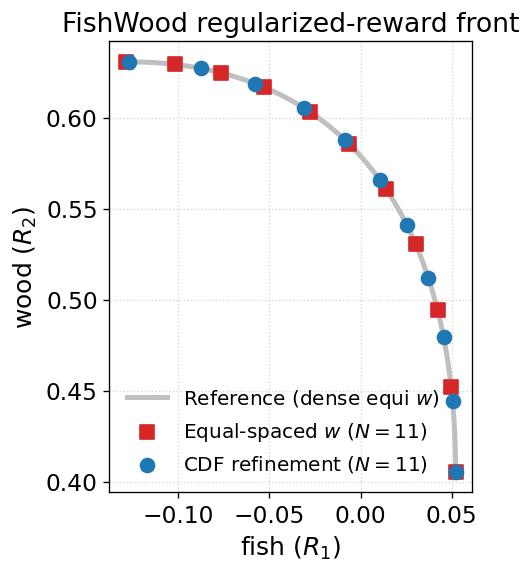

In [21]:
# Regularized rewards can be curved: (R1 - reg, R2 - reg)
def to_reg_points(results):
    arr = []
    for s in results:
        arr.append([s["R1"] - s["reg"], s["R2"] - s["reg"]])
    return np.asarray(arr, dtype=np.float64)

pf_ref_reg = to_reg_points(out_dense["results"])
pf_equi_reg = to_reg_points(out_equi["results"])
pf_cdf_reg = to_reg_points(out_cdf["policy_history"][-1])

fig, ax = plt.subplots()
ax.plot(pf_ref_reg[:, 0], pf_ref_reg[:, 1], color="0.75", lw=3, label="Reference (dense equi $w$)")
ax.scatter(pf_equi_reg[:, 0], pf_equi_reg[:, 1], s=80, marker="s", c="#d62728", zorder=5, label=f"Equal-spaced $w$ ($N={N_sparse}$)")
ax.scatter(pf_cdf_reg[:, 0], pf_cdf_reg[:, 1], s=70, c="#1f77b4", zorder=6, label=f"CDF refinement ($N={N_sparse}$)")

ax.set_xlabel(r"fish ($R_1 $)")
ax.set_ylabel(r"wood ($R_2 $)")
ax.set_title("FishWood regularized-reward front")
ax.legend(loc="best")
ax.set_aspect('equal', adjustable='box')

fp3 = FIG_PATH + "fishwood_pf_coverage.pdf"
# plt.savefig(fp3, bbox_inches="tight")
# plt.show()
# print("Saved", fp3)

## E. Additional baselines: Souping, UMOD, OLS, NBI, eps-constraint, continuation, equal-spacing

Ported from `Policy_update_DST_with_baseline.ipynb` (Figure-3 baselines). All methods share the same tabular inner solver (`solve_policy_scalarization` / `evaluate_policy_torch`) and the endpoint warm-starts `logits0`, `logits1` from cell 7. Section E aggregates mean ± std over `ALGO_SEEDS`.

This section ports the baseline structure from `Policy_update_DST_with_baseline.ipynb` and evaluates all methods with the same metrics function `pareto_metrics_vs_ref(...)` from Section D, plus **EpisodicDominance** (COLA: mean pairwise directed ED vs every other method; run Section D’s metrics cell first so `N_METRIC_REPLICATES`, `ED_N_EPISODES`, `ED_HORIZON`, and `ED_SEED` are defined).
Reported `*_std` in the comparison table is from **independent algorithm runs across `ALGO_SEEDS`** (algorithm randomness).

- **Souping**: direct logits interpolation between endpoint solutions.
- **UMOD**: surrogate-guided outer-loop over scalarization weights.
- **OLS**: MORL-Baselines linear-support outer loop (if `morl_baselines` is installed).

In [23]:
# ---- Baseline runners (ported/adapted from DST notebook) ----

def run_soup_weights_policy_baseline(
    N_points,
    P, R, rho0, gamma, tau, pi_ref,
    logits0,
    logits1,
    device=DEVICE,
):
    weights = np.linspace(0.0, 1.0, N_points)
    results = []

    P_t = torch.tensor(P, dtype=torch.float32, device=device)
    R_t = torch.tensor(R, dtype=torch.float32, device=device)
    rho0_t = torch.tensor(rho0, dtype=torch.float32, device=device)
    pi_ref_t = torch.tensor(pi_ref, dtype=torch.float32, device=device)

    for w in weights:
        logits_soup = (1.0 - w) * logits0 + w * logits1
        logits_t = torch.tensor(logits_soup, dtype=torch.float32, device=device)

        out = evaluate_policy_torch(logits_t, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)

        results.append({
            "w": float(w),
            "logits": logits_soup,
            "pi": out["pi"].detach().cpu().numpy(),
            "d": out["d"].detach().cpu().numpy(),
            "mu": out["mu"].detach().cpu().numpy(),
            "R1": float(out["R1"].detach().cpu().item()),
            "R2": float(out["R2"].detach().cpu().item()),
            "reg": float(out["reg"].detach().cpu().item()),
        })

    pf = np.array([[r["R1"], r["R2"]] for r in results], dtype=np.float32)
    return {"weights": weights, "results": results, "pf": pf}




def _make_env_tensors(P, R, rho0, pi_ref, device=DEVICE):
    P_t = torch.tensor(P, dtype=torch.float32, device=device)
    R_t = torch.tensor(R, dtype=torch.float32, device=device)
    rho0_t = torch.tensor(rho0, dtype=torch.float32, device=device)
    pi_ref_t = torch.tensor(pi_ref, dtype=torch.float32, device=device)
    return P_t, R_t, rho0_t, pi_ref_t


def _g_from_out(out):
    return out["R1"] - out["reg"], out["R2"] - out["reg"]


def _result_from_logits(logits_np, env_tensors, gamma, tau, w=None):
    P_t, R_t, rho0_t, pi_ref_t = env_tensors
    logits_t = torch.tensor(np.asarray(logits_np), dtype=torch.float32, device=P_t.device)
    with torch.no_grad():
        out = evaluate_policy_torch(logits_t, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
    return {
        "w": (float(w) if w is not None else None),
        "logits": np.asarray(logits_np, dtype=np.float32),
        "pi": out["pi"].detach().cpu().numpy(),
        "d": out["d"].detach().cpu().numpy(),
        "mu": out["mu"].detach().cpu().numpy(),
        "R1": float(out["R1"].item()),
        "R2": float(out["R2"].item()),
        "reg": float(out["reg"].item()),
    }


def _pack_fig3_baseline(results, weights, extra=None):
    pf = np.array([[r["R1"], r["R2"]] for r in results], dtype=np.float64)
    out = {
        "weights": np.asarray(weights, dtype=np.float64),
        "results": results,
        "pf": pf,
    }
    if extra is not None:
        out.update(extra)
    return out


def _solve_eps_constraint_single(eps, env_tensors, gamma, tau, S, A,
                                 logits_init=None, maxiter=3000, lr=0.02,
                                 rho=10.0, al_period=50, device=DEVICE):
    P_t, R_t, rho0_t, pi_ref_t = env_tensors
    if logits_init is None:
        logits = torch.zeros((S, A), dtype=torch.float32, device=device, requires_grad=True)
    else:
        logits = torch.tensor(np.asarray(logits_init), dtype=torch.float32,
                              device=device, requires_grad=True)
    opt = torch.optim.Adam([logits], lr=lr)
    lam = 0.0

    for it in range(maxiter):
        opt.zero_grad()
        out = evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
        g1, g2 = _g_from_out(out)
        c = eps - g2
        term = torch.clamp(lam + rho * c, min=0.0)
        al = (term ** 2 - lam ** 2) / (2.0 * rho)
        loss = -g1 + al
        loss.backward()
        opt.step()

        if (it + 1) % al_period == 0:
            with torch.no_grad():
                out2 = evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
                _, g2v = _g_from_out(out2)
                lam = max(0.0, lam + rho * float((eps - g2v).item()))

    with torch.no_grad():
        out = evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
        _, g2v = _g_from_out(out)
        cviol = max(0.0, float((eps - g2v).item()))
    return logits.detach().cpu().numpy(), lam, cviol


def run_eps_constraint_policy_baseline(
    N_points, P, R, rho0, gamma, tau, pi_ref,
    logits0=None, logits1=None,
    inner_maxiter=3000, inner_lr=0.02,
    rho=50.0, al_period=50,
    device=DEVICE, verbose=False,
):
    env = _make_env_tensors(P, R, rho0, pi_ref, device=device)
    S, A = pi_ref.shape

    if logits0 is None:
        logits0 = solve_policy_scalarization(0.0, P, R, rho0, gamma, tau, pi_ref,
                                             lr=inner_lr, maxiter=inner_maxiter,
                                             device=device)["logits"]
    if logits1 is None:
        logits1 = solve_policy_scalarization(1.0, P, R, rho0, gamma, tau, pi_ref,
                                             lr=inner_lr, maxiter=inner_maxiter,
                                             device=device)["logits"]
    res0 = _result_from_logits(logits0, env, gamma, tau, w=0.0)
    res1 = _result_from_logits(logits1, env, gamma, tau, w=1.0)
    g2_lo = res0["R2"] - res0["reg"]
    g2_hi = res1["R2"] - res1["reg"]
    eps_grid = np.linspace(g2_lo, g2_hi, N_points)

    results = []
    cviols = []
    prev_logits = logits0
    for k, eps in enumerate(eps_grid):
        if k == 0:
            results.append(res0)
            cviols.append(0.0)
            prev_logits = logits0
            continue
        if k == N_points - 1:
            results.append(res1)
            cviols.append(0.0)
            prev_logits = logits1
            continue

        logits_k, _, cviol = _solve_eps_constraint_single(
            float(eps), env, gamma, tau, S, A,
            logits_init=prev_logits, maxiter=inner_maxiter, lr=inner_lr,
            rho=rho, al_period=al_period, device=device,
        )
        res = _result_from_logits(logits_k, env, gamma, tau, w=None)
        results.append(res)
        cviols.append(cviol)
        prev_logits = logits_k

    weights = (eps_grid - g2_lo) / (g2_hi - g2_lo + 1e-12)
    return _pack_fig3_baseline(
        results, weights,
        extra={"eps_grid": eps_grid, "max_constraint_violation": float(np.max(cviols))},
    )


def _solve_nbi_single(p_k, nhat, env_tensors, gamma, tau, S, A,
                      logits_init=None, t_init=0.0, maxiter=3000, lr=0.02,
                      rho=10.0, al_period=50, device=DEVICE):
    P_t, R_t, rho0_t, pi_ref_t = env_tensors
    if logits_init is None:
        logits = torch.zeros((S, A), dtype=torch.float32, device=device, requires_grad=True)
    else:
        logits = torch.tensor(np.asarray(logits_init), dtype=torch.float32,
                              device=device, requires_grad=True)
    t = torch.tensor(float(t_init), dtype=torch.float32, device=device, requires_grad=True)
    opt = torch.optim.Adam([logits, t], lr=lr)

    nhat_t = torch.tensor(np.asarray(nhat), dtype=torch.float32, device=device)
    p_t = torch.tensor(np.asarray(p_k), dtype=torch.float32, device=device)
    lam = torch.zeros(2, dtype=torch.float32, device=device)

    def cost_vec(out):
        g1, g2 = _g_from_out(out)
        return torch.stack([-g1, -g2])

    for it in range(maxiter):
        opt.zero_grad()
        out = evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
        r = cost_vec(out) - p_t - t * nhat_t
        loss = -t + torch.dot(lam, r) + 0.5 * rho * torch.dot(r, r)
        loss.backward()
        opt.step()

        if (it + 1) % al_period == 0:
            with torch.no_grad():
                out2 = evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
                r2 = cost_vec(out2) - p_t - t * nhat_t
                lam = lam + rho * r2

    with torch.no_grad():
        out = evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
        r = cost_vec(out) - p_t - t * nhat_t
        rnorm = float(torch.linalg.norm(r).item())
    return logits.detach().cpu().numpy(), float(t.detach().item()), rnorm


def run_nbi_policy_baseline(
    N_points, P, R, rho0, gamma, tau, pi_ref,
    logits0=None, logits1=None,
    inner_maxiter=3000, inner_lr=0.02,
    rho=10.0, al_period=50,
    device=DEVICE, verbose=False,
):
    env = _make_env_tensors(P, R, rho0, pi_ref, device=device)
    S, A = pi_ref.shape

    if logits0 is None:
        logits0 = solve_policy_scalarization(0.0, P, R, rho0, gamma, tau, pi_ref,
                                             lr=inner_lr, maxiter=inner_maxiter,
                                             device=device)["logits"]
    if logits1 is None:
        logits1 = solve_policy_scalarization(1.0, P, R, rho0, gamma, tau, pi_ref,
                                             lr=inner_lr, maxiter=inner_maxiter,
                                             device=device)["logits"]
    res0 = _result_from_logits(logits0, env, gamma, tau, w=0.0)
    res1 = _result_from_logits(logits1, env, gamma, tau, w=1.0)

    A_cost = np.array([-(res0["R1"] - res0["reg"]), -(res0["R2"] - res0["reg"])])
    B_cost = np.array([-(res1["R1"] - res1["reg"]), -(res1["R2"] - res1["reg"])])
    utopia = np.minimum(A_cost, B_cost)
    Phi = np.stack([A_cost - utopia, B_cost - utopia], axis=1)
    nhat = -(Phi @ np.ones(2)) / (np.linalg.norm(Phi @ np.ones(2)) + 1e-12)

    betas = np.linspace(0.0, 1.0, N_points)
    results = []
    rnorms = []
    prev_logits = logits0
    t_prev = 0.0
    for k, beta in enumerate(betas):
        if k == 0:
            results.append(res0)
            rnorms.append(0.0)
            prev_logits = logits0
            continue
        if k == N_points - 1:
            results.append(res1)
            rnorms.append(0.0)
            prev_logits = logits1
            continue

        p_k = (1.0 - beta) * A_cost + beta * B_cost
        logits_k, t_k, rnorm = _solve_nbi_single(
            p_k, nhat, env, gamma, tau, S, A,
            logits_init=prev_logits, t_init=t_prev, maxiter=inner_maxiter, lr=inner_lr,
            rho=rho, al_period=al_period, device=device,
        )
        res = _result_from_logits(logits_k, env, gamma, tau, w=None)
        results.append(res)
        rnorms.append(rnorm)
        prev_logits = logits_k
        t_prev = t_k

    return _pack_fig3_baseline(
        results, betas,
        extra={"nhat": nhat, "Phi": Phi, "max_constraint_residual": float(np.max(rnorms))},
    )


def run_continuation_arclength_policy_baseline(
    N_points, P, R, rho0, gamma, tau, pi_ref,
    logits0=None, logits1=None,
    inner_maxiter=300, inner_lr=0.02, inner_tol=1e-8,
    n_probe=5, probe_maxiter=None, bisect_iters=12, chord_rtol=2e-2,
    device=DEVICE, verbose=False,
):
    if probe_maxiter is None:
        probe_maxiter = inner_maxiter

    env = _make_env_tensors(P, R, rho0, pi_ref, device=device)
    tiny = 1e-12

    def g_of(res):
        return np.array([res["R1"] - res["reg"], res["R2"] - res["reg"]], dtype=np.float64)

    if logits0 is None:
        logits0 = solve_policy_scalarization(0.0, P, R, rho0, gamma, tau, pi_ref,
                                             lr=inner_lr, maxiter=inner_maxiter,
                                             device=device)["logits"]
    if logits1 is None:
        logits1 = solve_policy_scalarization(1.0, P, R, rho0, gamma, tau, pi_ref,
                                             lr=inner_lr, maxiter=inner_maxiter,
                                             device=device)["logits"]
    res0 = _result_from_logits(logits0, env, gamma, tau, w=0.0)
    res1 = _result_from_logits(logits1, env, gamma, tau, w=1.0)

    n_queries = 0

    def solve_w(w, init):
        nonlocal n_queries
        sol = solve_policy_scalarization(float(w), P, R, rho0, gamma, tau, pi_ref,
                                         logits_init=init, lr=inner_lr,
                                         maxiter=inner_maxiter, tol=inner_tol, device=device)
        n_queries += 1
        return sol

    probe_ws = np.linspace(0.0, 1.0, n_probe)
    probe_F = []
    prev = logits0
    for j, w in enumerate(probe_ws):
        if j == 0:
            probe_F.append(g_of(res0))
            prev = logits0
            continue
        if j == n_probe - 1:
            probe_F.append(g_of(res1))
            prev = logits1
            continue
        sol = solve_w(w, prev)
        probe_F.append(np.array([sol["R1"] - sol["reg"], sol["R2"] - sol["reg"]]))
        prev = sol["logits"]
    probe_F = np.asarray(probe_F)
    L_tot = float(np.sum(np.linalg.norm(np.diff(probe_F, axis=0), axis=1)))
    v_est = max(np.linalg.norm(probe_F[1] - probe_F[0]) / max(probe_ws[1] - probe_ws[0], tiny), tiny)

    results = [res0]
    weights = [0.0]
    chords = []
    w_cur, F_cur, logits_cur, s_cur = 0.0, g_of(res0), logits0, 0.0

    for n in range(1, N_points):
        if n == N_points - 1:
            res_new, logits_new, w_new = res1, logits1, 1.0
            chord = float(np.linalg.norm(g_of(res1) - F_cur))
            F_new = g_of(res1)
        else:
            target = max(L_tot - s_cur, tiny) / (N_points - n)
            lo, hi = w_cur, 1.0
            mid = min(1.0 - 1e-6, max(w_cur + 1e-6, w_cur + target / max(v_est, tiny)))
            best = None
            for _ in range(bisect_iters):
                sol = solve_w(mid, logits_cur)
                F_try = np.array([sol["R1"] - sol["reg"], sol["R2"] - sol["reg"]])
                chord = float(np.linalg.norm(F_try - F_cur))
                best = (mid, sol, F_try, chord)
                if abs(chord - target) <= chord_rtol * target:
                    break
                if chord < target:
                    lo = mid
                else:
                    hi = mid
                mid = 0.5 * (lo + hi)
            mid, sol, F_try, chord = best
            w_new, F_new, logits_new = mid, F_try, sol["logits"]
            res_new = _result_from_logits(sol["logits"], env, gamma, tau, w=float(mid))

        v_est = max(chord / max(w_new - w_cur, tiny), tiny)
        s_cur += chord
        results.append(res_new)
        weights.append(float(w_new))
        chords.append(chord)
        w_cur, F_cur, logits_cur = w_new, F_new, logits_new

    return _pack_fig3_baseline(
        results, weights,
        extra={"L_tot_estimate": L_tot, "chords": np.asarray(chords), "num_queries": n_queries},
    )


def run_equal_spacing_continuation_policy_baseline(
    N_points, P, R, rho0, gamma, tau, pi_ref,
    logits0=None, logits1=None,
    inner_maxiter=300, inner_lr=0.02, inner_tol=1e-8,
    n_probe=9, probe_maxiter=None,
    bisect_iters=22, chord_rtol=5e-3, n_refine=0, alpha_gamma=1.0,
    device=DEVICE, verbose=False,
):
    if probe_maxiter is None:
        probe_maxiter = inner_maxiter

    env = _make_env_tensors(P, R, rho0, pi_ref, device=device)

    def g_of(res):
        return np.array([res["R1"] - res["reg"], res["R2"] - res["reg"]], dtype=np.float64)

    if logits0 is None:
        logits0 = solve_policy_scalarization(0.0, P, R, rho0, gamma, tau, pi_ref,
                                             lr=inner_lr, maxiter=inner_maxiter, device=device)["logits"]
    if logits1 is None:
        logits1 = solve_policy_scalarization(1.0, P, R, rho0, gamma, tau, pi_ref,
                                             lr=inner_lr, maxiter=inner_maxiter, device=device)["logits"]
    res0 = _result_from_logits(logits0, env, gamma, tau, w=0.0)
    res1 = _result_from_logits(logits1, env, gamma, tau, w=1.0)
    F0, F1 = g_of(res0), g_of(res1)

    n_queries = 0

    def solve_w(w, init):
        nonlocal n_queries
        sol = solve_policy_scalarization(float(w), P, R, rho0, gamma, tau, pi_ref,
                                         logits_init=init, lr=inner_lr,
                                         maxiter=inner_maxiter, tol=inner_tol, device=device)
        n_queries += 1
        return sol

    probe_ws = np.linspace(0.0, 1.0, n_probe)
    probe_F = []
    prev = logits0
    for j, w in enumerate(probe_ws):
        if j == 0:
            probe_F.append(F0)
            prev = logits0
            continue
        if j == n_probe - 1:
            probe_F.append(F1)
            prev = logits1
            continue
        sol = solve_w(w, prev)
        probe_F.append(np.array([sol["R1"] - sol["reg"], sol["R2"] - sol["reg"]]))
        prev = sol["logits"]
    probe_F = np.asarray(probe_F)
    L_probe = float(np.sum(np.linalg.norm(np.diff(probe_F, axis=0), axis=1)))
    gamma_val = max(alpha_gamma * float(np.linalg.norm(F0 - F1)), L_probe) / (N_points - 1)

    def sequential_pass(gamma_target):
        results = [res0]
        weights = [0.0]
        chords = []
        w_cur, F_cur, logits_cur = 0.0, F0, logits0
        for n in range(1, N_points - 1):
            lo, hi = w_cur, 1.0
            mid = 0.5 * (lo + hi)
            best = None
            for _ in range(bisect_iters):
                sol = solve_w(mid, logits_cur)
                F_try = np.array([sol["R1"] - sol["reg"], sol["R2"] - sol["reg"]])
                c = float(np.linalg.norm(F_try - F_cur))
                best = (mid, sol, F_try, c)
                if abs(c - gamma_target) <= chord_rtol * gamma_target:
                    break
                if c < gamma_target:
                    lo = mid
                else:
                    hi = mid
                mid = 0.5 * (lo + hi)
            mid, sol, F_try, c = best
            results.append(_result_from_logits(sol["logits"], env, gamma, tau, w=float(mid)))
            weights.append(float(mid))
            chords.append(c)
            w_cur, F_cur, logits_cur = mid, F_try, sol["logits"]
        results.append(res1)
        weights.append(1.0)
        chords.append(float(np.linalg.norm(F1 - F_cur)))
        return results, weights, chords

    results, weights, chords = sequential_pass(gamma_val)
    for _ in range(max(n_refine, 0)):
        gamma_val = float(np.sum(chords)) / (N_points - 1)
        results, weights, chords = sequential_pass(gamma_val)

    return _pack_fig3_baseline(
        results, weights,
        extra={"gamma": gamma_val, "L_probe": L_probe, "chords": np.asarray(chords), "num_queries": n_queries},
    )

class UMODPFModel(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, theta):
        if theta.ndim == 1:
            theta = theta[:, None]
        return self.net(theta)


def run_umod_policy_baseline(
    N_points,
    P, R, rho0, gamma, tau, pi_ref,
    inner_maxiter=100,
    inner_lr=0.05,
    inner_tol=1e-8,
    logits0=None,
    logits1=None,
    duplicate_tol=1e-6,
    max_outer_iters=8,
    pf_model_hidden=64,
    pf_model_epochs=120,
    pf_model_lr=1e-3,
    theta_step=0.05,
    max_total_queries=None,
    device=DEVICE,
    verbose=False,
):
    if max_total_queries is None:
        max_total_queries = max(8 * N_points, 40)

    def theta_to_weightvec(theta_vals):
        theta_vals = np.asarray(theta_vals, dtype=np.float64)
        return np.stack([1.0 - theta_vals, theta_vals], axis=1)

    def is_duplicate_solution(sol, accepted, tol=duplicate_tol):
        p = np.array([sol["R1"], sol["R2"], sol["reg"]], dtype=np.float64)
        for old in accepted:
            q = np.array([old["R1"], old["R2"], old["reg"]], dtype=np.float64)
            if np.linalg.norm(p - q, ord=2) < tol:
                return True
        return False

    def fit_pf_model(theta_vals, pf_vals):
        model = UMODPFModel(hidden_dim=pf_model_hidden).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=pf_model_lr)

        x = torch.tensor(theta_vals, dtype=torch.float32, device=device)[:, None]
        y = torch.tensor(pf_vals, dtype=torch.float32, device=device)

        for _ in range(pf_model_epochs):
            pred = model(x)
            loss = ((pred - y) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()

        return model

    def update_thetas_with_surrogate(theta_vals, model):
        theta_t = torch.tensor(theta_vals, dtype=torch.float32, device=device, requires_grad=True)
        pred = model(theta_t[:, None])

        K = pred.shape[0]
        dmin = None
        for i in range(K):
            for j in range(i + 1, K):
                d = torch.norm(pred[i] - pred[j], p=2)
                if dmin is None or d < dmin:
                    dmin = d

        if dmin is None:
            return np.sort(np.clip(theta_vals, 0.0, 1.0))

        loss = -dmin
        loss.backward()

        with torch.no_grad():
            theta_new = theta_t - theta_step * theta_t.grad
            theta_new = torch.clamp(theta_new, 0.0, 1.0)
            theta_new, _ = torch.sort(theta_new)
            theta_new[0] = 0.0
            theta_new[-1] = 1.0

        return theta_new.detach().cpu().numpy()

    def interp_logits(w):
        if logits0 is None or logits1 is None:
            return None
        return (1.0 - w) * logits0 + w * logits1

    theta = np.linspace(0.0, 1.0, N_points, dtype=np.float64)
    theta_history = [theta.copy()]

    accepted_results = []
    accepted_weight_vecs = []
    num_queries = 0

    prev_outer_scalar_ws = None
    prev_outer_logits = None

    for outer_it in range(max_outer_iters):
        weight_vecs = theta_to_weightvec(theta)

        current_results = []
        current_weight_vecs = []
        current_logits = []

        for k, w_vec in enumerate(weight_vecs):
            if num_queries >= max_total_queries:
                break

            w_vec = np.asarray(w_vec, dtype=np.float64)
            w_vec = w_vec / w_vec.sum()
            w = float(w_vec[1])

            logits_init = None
            if prev_outer_scalar_ws is not None and prev_outer_logits is not None and len(prev_outer_scalar_ws) > 0:
                idx = int(np.argmin(np.abs(prev_outer_scalar_ws - w)))
                logits_init = prev_outer_logits[idx]
            if logits_init is None and len(current_logits) > 0:
                logits_init = current_logits[-1]
            if logits_init is None:
                logits_init = interp_logits(w)

            sol = solve_policy_scalarization(
                w=w,
                P=P,
                R=R,
                rho0=rho0,
                gamma=gamma,
                tau=tau,
                pi_ref=pi_ref,
                logits_init=logits_init,
                lr=inner_lr,
                maxiter=inner_maxiter,
                tol=inner_tol,
                device=device,
                verbose=False,
            )
            num_queries += 1

            if not is_duplicate_solution(sol, current_results, tol=duplicate_tol):
                current_results.append(sol)
                current_weight_vecs.append(w_vec)
                current_logits.append(np.array(sol["logits"], copy=True))

        if len(current_results) == 0:
            break

        scalar_ws = np.array([wv[1] for wv in current_weight_vecs], dtype=np.float64)
        order = np.argsort(scalar_ws)
        current_results = [current_results[i] for i in order]
        current_weight_vecs = np.array(current_weight_vecs, dtype=np.float64)[order]
        scalar_ws = scalar_ws[order]
        current_logits = [current_logits[i] for i in order]

        # keep latest non-duplicate batch as candidate output
        accepted_results = current_results
        accepted_weight_vecs = current_weight_vecs

        # train surrogate on regularized objectives (same spirit as DST UMOD)
        pf_vals = np.array(
            [[r["R1"] - r["reg"], r["R2"] - r["reg"]] for r in current_results],
            dtype=np.float64,
        )

        if len(pf_vals) >= 3:
            model = fit_pf_model(scalar_ws, pf_vals)
            theta = update_thetas_with_surrogate(theta, model)
            theta_history.append(theta.copy())

        prev_outer_scalar_ws = scalar_ws.copy()
        prev_outer_logits = current_logits.copy()

    if len(accepted_results) == 0:
        return {
            "weights": np.zeros((0, 2)),
            "scalar_weights": np.zeros((0,)),
            "results": [],
            "pf": np.zeros((0, 2)),
            "num_queries": num_queries,
            "theta_history": theta_history,
        }

    scalar_ws = np.array([wv[1] for wv in accepted_weight_vecs], dtype=np.float64)
    order = np.argsort(scalar_ws)
    accepted_results = [accepted_results[i] for i in order]
    accepted_weight_vecs = np.array(accepted_weight_vecs, dtype=np.float64)[order]
    scalar_ws = scalar_ws[order]

    pf = np.array([[r["R1"], r["R2"]] for r in accepted_results], dtype=np.float64)

    return {
        "weights": accepted_weight_vecs,
        "scalar_weights": scalar_ws,
        "results": accepted_results,
        "pf": pf,
        "num_queries": num_queries,
        "theta_history": theta_history,
    }


def run_ols_policy_baseline(
    N_points,
    P, R, rho0, gamma, tau, pi_ref,
    inner_maxiter=300,
    inner_lr=0.05,
    inner_tol=1e-8,
    epsilon_ols=1e-6,
    logits0=None,
    logits1=None,
    init_mode="interp",
    duplicate_tol=1e-6,
    max_total_queries=None,
    device=DEVICE,
    verbose=False,
):
    # morl_baselines still uses np.round_, removed in NumPy 2.0.
    if not hasattr(np, "round_"):
        np.round_ = np.round
    try:
        from morl_baselines.multi_policy.linear_support.linear_support import LinearSupport
    except Exception as e:
        print(f"[OLS skipped] morl_baselines unavailable: {e}")
        return None

    ols = LinearSupport(num_objectives=2, epsilon=epsilon_ols, verbose=verbose)

    accepted_results = []
    accepted_weight_vecs = []
    prev_logits = None
    num_queries = 0

    if max_total_queries is None:
        max_total_queries = max(10 * N_points, 50)

    def is_duplicate_solution(sol, accepted, tol=duplicate_tol):
        p = np.array([sol["R1"], sol["R2"], sol["reg"]], dtype=np.float64)
        for old in accepted:
            q = np.array([old["R1"], old["R2"], old["reg"]], dtype=np.float64)
            if np.linalg.norm(p - q, ord=2) < tol:
                return True
        return False

    while len(accepted_results) < N_points and num_queries < max_total_queries:
        w_vec = ols.next_weight(algo="ols")
        if w_vec is None:
            break

        w_vec = np.asarray(w_vec, dtype=np.float64)
        if w_vec.sum() <= 0:
            break
        w_vec = w_vec / w_vec.sum()
        w = float(w_vec[1])

        if init_mode == "interp" and logits0 is not None and logits1 is not None:
            logits_init = (1.0 - w) * logits0 + w * logits1
        elif init_mode == "prev" and prev_logits is not None:
            logits_init = prev_logits
        else:
            logits_init = None

        sol = solve_policy_scalarization(
            w=w,
            P=P,
            R=R,
            rho0=rho0,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            logits_init=logits_init,
            lr=inner_lr,
            maxiter=inner_maxiter,
            tol=inner_tol,
            device=device,
            verbose=False,
        )
        num_queries += 1

        value = np.array([sol["R1"] - sol["reg"], sol["R2"] - sol["reg"]], dtype=np.float64)
        ols.add_solution(value=value, w=w_vec)

        if not is_duplicate_solution(sol, accepted_results, tol=duplicate_tol):
            accepted_results.append(sol)
            accepted_weight_vecs.append(w_vec)
            prev_logits = np.array(sol["logits"], copy=True)

        if ols.ended():
            break

    if len(accepted_results) == 0:
        return {
            "weights": np.zeros((0, 2)),
            "scalar_weights": np.zeros((0,)),
            "results": [],
            "pf": np.zeros((0, 2)),
            "num_queries": num_queries,
        }

    scalar_ws = np.array([wv[1] for wv in accepted_weight_vecs], dtype=np.float64)
    order = np.argsort(scalar_ws)

    accepted_results = [accepted_results[i] for i in order]
    accepted_weight_vecs = np.array(accepted_weight_vecs, dtype=np.float64)[order]
    scalar_ws = scalar_ws[order]

    pf = np.array([[r["R1"], r["R2"]] for r in accepted_results], dtype=np.float64)

    return {
        "weights": accepted_weight_vecs,
        "scalar_weights": scalar_ws,
        "results": accepted_results,
        "pf": pf,
        "num_queries": num_queries,
    }


# ---- Optional single-run smoke test (same hyperparameters as Section E loop below) ----
out_soup = run_soup_weights_policy_baseline(
    N_sparse, P, R, rho0, gamma, tau, pi_ref,
    logits0=logits0, logits1=logits1,
)

out_umod = run_umod_policy_baseline(
    N_sparse, P, R, rho0, gamma, tau, pi_ref,
    logits0=logits0, logits1=logits1,
    inner_maxiter=INNER_MAXITER,
    inner_lr=INNER_LR,
    max_outer_iters=UMOD_MAX_OUTER_ITERS,
    pf_model_epochs=UMOD_PF_MODEL_EPOCHS,
    verbose=False,
)

out_ols = None
try:
    out_ols = run_ols_policy_baseline(
        N_sparse, P, R, rho0, gamma, tau, pi_ref,
        logits0=logits0, logits1=logits1,
        inner_maxiter=OLS_INNER_MAXITER,
        inner_lr=INNER_LR,
        verbose=False,
    )
except Exception as e:
    print(f"[OLS smoke test skipped] {e}")


# ---- Metrics aggregation (algorithm-randomness over ALGO_SEEDS) ----
import random

# ALGO_SEEDS defined in cell 7 (experiment setup)


def set_all_seeds(seed: int):
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


# per-method metric vectors across algorithm seeds
method_metric_series = {}

for si, seed in enumerate(ALGO_SEEDS):
    set_all_seeds(seed)

    out_equi_s = run_equispace_weights_policy_baseline(
        N_sparse, P, R, rho0, gamma, tau, pi_ref,
        inner_maxiter=INNER_MAXITER, inner_lr=INNER_LR,
    )
    out_cdf_s = solve_cdf_refinement_policy(
        N_sparse, P, R, rho0, gamma, tau, pi_ref,
        max_outer_iters=CDF_MAX_OUTER_ITERS,
        alpha=CDF_ALPHA,
        logits0=logits0, logits1=logits1,
        init_from_prev=CDF_INIT_FROM_PREV,
        inner_maxiter=INNER_MAXITER,
        inner_lr=INNER_LR,
        verbose=False,
    )
    out_soup_s = run_soup_weights_policy_baseline(
        N_sparse, P, R, rho0, gamma, tau, pi_ref,
        logits0=logits0, logits1=logits1,
    )
    out_umod_s = run_umod_policy_baseline(
        N_sparse, P, R, rho0, gamma, tau, pi_ref,
        logits0=logits0, logits1=logits1,
        inner_maxiter=INNER_MAXITER,
        inner_lr=INNER_LR,
        max_outer_iters=UMOD_MAX_OUTER_ITERS,
        pf_model_epochs=UMOD_PF_MODEL_EPOCHS,
        verbose=False,
    )

    out_ols_s = None
    try:
        out_ols_s = run_ols_policy_baseline(
            N_sparse, P, R, rho0, gamma, tau, pi_ref,
            logits0=logits0, logits1=logits1,
            inner_maxiter=OLS_INNER_MAXITER,
            inner_lr=INNER_LR,
            verbose=False,
        )
    except Exception as e:
        print(f"[OLS seed {seed}] skipped: {e}")
        out_ols_s = None

    all_pf_s = {
        "Equal-spaced": np.asarray(out_equi_s["pf"], dtype=np.float64),
        "CDF": np.asarray(out_cdf_s["pf_history"][-1], dtype=np.float64),
        "Souping": np.asarray(out_soup_s["pf"], dtype=np.float64),
        "UMOD": np.asarray(out_umod_s["pf"], dtype=np.float64),
    }

    all_results_s = {
        "Equal-spaced": out_equi_s["results"],
        "CDF": out_cdf_s["policy_history"][-1],
        "Souping": out_soup_s["results"],
        "UMOD": out_umod_s["results"],
    }

    out_eps_s = run_eps_constraint_policy_baseline(
        N_sparse, P, R, rho0, gamma, tau, pi_ref,
        logits0=logits0, logits1=logits1,
        inner_maxiter=FIG3_AL_INNER_MAXITER,
        inner_lr=FIG3_AL_INNER_LR,
        rho=FIG3_EPS_RHO,
        al_period=FIG3_AL_PERIOD,
        device=DEVICE,
        verbose=False,
    )
    out_nbi_s = run_nbi_policy_baseline(
        N_sparse, P, R, rho0, gamma, tau, pi_ref,
        logits0=logits0, logits1=logits1,
        inner_maxiter=FIG3_AL_INNER_MAXITER,
        inner_lr=FIG3_AL_INNER_LR,
        rho=FIG3_NBI_RHO,
        al_period=FIG3_AL_PERIOD,
        device=DEVICE,
        verbose=False,
    )
    out_cont_s = run_continuation_arclength_policy_baseline(
        N_sparse, P, R, rho0, gamma, tau, pi_ref,
        logits0=logits0, logits1=logits1,
        inner_maxiter=FIG3_CONT_INNER_MAXITER,
        inner_lr=FIG3_CONT_INNER_LR,
        n_probe=FIG3_CONT_N_PROBE,
        probe_maxiter=FIG3_CONT_INNER_MAXITER,
        device=DEVICE,
        verbose=False,
    )
    out_eqsp_s = run_equal_spacing_continuation_policy_baseline(
        N_sparse, P, R, rho0, gamma, tau, pi_ref,
        logits0=logits0, logits1=logits1,
        inner_maxiter=FIG3_EQSP_INNER_MAXITER,
        inner_lr=FIG3_EQSP_INNER_LR,
        n_probe=FIG3_EQSP_N_PROBE,
        bisect_iters=FIG3_EQSP_BISECT_ITERS,
        chord_rtol=FIG3_EQSP_CHORD_RTOL,
        device=DEVICE,
        verbose=False,
    )

    all_pf_s["NBI"] = np.asarray(out_nbi_s["pf"], dtype=np.float64)
    all_pf_s["eps-constraint"] = np.asarray(out_eps_s["pf"], dtype=np.float64)
    all_pf_s["Continuation"] = np.asarray(out_cont_s["pf"], dtype=np.float64)
    all_pf_s["Equal-spacing"] = np.asarray(out_eqsp_s["pf"], dtype=np.float64)

    all_results_s["NBI"] = out_nbi_s["results"]
    all_results_s["eps-constraint"] = out_eps_s["results"]
    all_results_s["Continuation"] = out_cont_s["results"]
    all_results_s["Equal-spacing"] = out_eqsp_s["results"]

    if out_ols_s is not None:
        all_pf_s["OLS"] = np.asarray(out_ols_s["pf"], dtype=np.float64)
        all_results_s["OLS"] = out_ols_s["results"]

    for name, pf in all_pf_s.items():
        m = pareto_metrics_vs_ref(
            pf, ref_pf, hv_ref_pymoo=HV_REF_PYMOO, hv_ref_sweep=HV_REF_SWEEP
        )
        # m["MeanUtility"] = float(np.mean(expected_utility_per_solution(all_results_s[name])))
        # m["EpisodicDominance"] = mean_pairwise_cola_ed(
        #     all_results_s,
        #     name,
        #     fishproba,
        #     woodproba,
        #     n_episodes=ED_N_EPISODES,
        #     horizon=ED_HORIZON,
        #     base_seed=ED_SEED + 10007 * si,
        # )

        if name not in method_metric_series:
            method_metric_series[name] = {k: [] for k in m.keys()}
        for k, v in m.items():
            method_metric_series[name][k].append(v)


def mean_std_finite(vals):
    a = np.asarray(vals, dtype=float)
    a = a[np.isfinite(a)]
    if len(a) == 0:
        return np.nan, np.nan
    if len(a) == 1:
        return float(a[0]), np.nan
    return float(np.mean(a)), float(np.std(a, ddof=1))


rows = []
for name, series in method_metric_series.items():
    row = {"Method": name}
    for k, slug in _PF_METRIC_SPEC:
        mu, sig = mean_std_finite(series.get(k, []))
        row[f"{slug}_mean"] = mu
        row[f"{slug}_std"] = sig

    mu_u, sig_u = mean_std_finite(series.get("MeanUtility", []))
    row["MeanUtility_mean"] = mu_u
    row["MeanUtility_std"] = sig_u

    mu_ed, sig_ed = mean_std_finite(series.get("EpisodicDominance", []))
    row["EpisodicDominance_mean"] = mu_ed
    row["EpisodicDominance_std"] = sig_ed

    rows.append(row)

_metric_cols = []
for _, slug in _PF_METRIC_SPEC:
    _metric_cols.extend([f"{slug}_mean", f"{slug}_std"])
_metric_cols.extend(
    ["MeanUtility_mean", "MeanUtility_std", "EpisodicDominance_mean", "EpisodicDominance_std"]
)

try:
    import pandas as pd
    cols = ["Method"] + _metric_cols
    df = pd.DataFrame(rows)
    df = df[cols]
    display(df.sort_values("Method").reset_index(drop=True))
except Exception:
    for r in rows:
        print("\n", r["Method"])
        for c in _metric_cols:
            v = r[c]
            print(f"  {c}: {v:.6g}" if np.isfinite(v) else f"  {c}: nan")


,Method,Err_arc_mean,Err_arc_std,CV_mean,CV_std,GapRatio_m1_mean,GapRatio_m1_std,IGD_mean,IGD_std,HV_pymoo_mean,HV_pymoo_std,HV_sweep_mean,HV_sweep_std,MeanUtility_mean,MeanUtility_std,EpisodicDominance_mean,EpisodicDominance_std
0,CDF,0.025589,3.657118e-18,0.025589,3.657118e-18,0.119805,0.000000e+00,0.009037,0.000000e+00,0.239434,0.000000e+00,0.239434,0.000000e+00,NaN,NaN,NaN,NaN
1,Continuation,0.101853,1.462847e-17,0.101853,1.462847e-17,0.334898,0.000000e+00,0.009060,1.828559e-18,0.239443,0.000000e+00,0.239443,2.925695e-17,NaN,NaN,NaN,NaN
2,Equal-spaced,0.194023,0.000000e+00,0.194023,2.925695e-17,0.750609,0.000000e+00,0.009140,0.000000e+00,0.239736,0.000000e+00,0.239736,2.925695e-17,NaN,NaN,NaN,NaN
3,Equal-spacing,0.106201,0.000000e+00,0.106201,0.000000e+00,0.363581,0.000000e+00,0.009086,0.000000e+00,0.239442,0.000000e+00,0.239442,0.000000e+00,NaN,NaN,NaN,NaN
4,NBI,0.062959,0.000000e+00,0.062959,0.000000e+00,0.223099,5.851389e-17,0.008993,0.000000e+00,0.239447,2.925695e-17,0.239447,0.000000e+00,NaN,NaN,NaN,NaN
5,OLS,0.356748,5.851389e-17,0.356748,5.851389e-17,1.487752,0.000000e+00,0.009615,1.828559e-18,0.239341,2.925695e-17,0.239341,2.925695e-17,NaN,NaN,NaN,NaN
6,Souping,0.199760,2.925695e-17,0.199760,2.925695e-17,0.895647,0.000000e+00,0.009095,1.828559e-18,0.239421,0.000000e+00,0.239421,0.000000e+00,NaN,NaN,NaN,NaN
7,UMOD,0.232849,1.713892e-02,0.232849,1.713892e-02,1.141259,1.125970e-01,0.009216,5.905496e-05,0.239410,6.054744e-06,0.239410,6.054744e-06,NaN,NaN,NaN,NaN
8,eps-constraint,0.640597,0.000000e+00,0.640597,0.000000e+00,3.912183,4.681111e-16,0.014507,1.828559e-18,0.239148,2.925695e-17,0.239148,2.925695e-17,NaN,NaN,NaN,NaN
